# Psychometric Emotion Network Analysis - Mental Health Reddit Posts

Network analysis of emotion co-occurrence patterns across 36,177 mental health Reddit posts.

**Data:** 28 GoEmotions probabilities per post, 19 BERTopic clusters, 18 subreddits

**Method:** Gaussian Graphical Model (GGM) with LASSO regularization for sparse network estimation

In [24]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Install required packages
!pip install -q networkx scipy scikit-learn pandas numpy matplotlib seaborn
!pip install -q python-louvain pyvis plotly

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
import json
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Network analysis
import networkx as nx
from sklearn.covariance import GraphicalLassoCV
from scipy.stats import spearmanr
from scipy.spatial.distance import pdist, squareform

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from pyvis.network import Network as PyvisNetwork
import plotly.graph_objects as go

# Community detection
import community.community_louvain as community_louvain

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100

print("Packages loaded successfully")

Packages loaded successfully


In [26]:
# Setup directories
BASE_DIR = Path("/content/drive/MyDrive/mental_health_research_V2")
BERTOPIC_DIR = BASE_DIR / "results" / "bertopic_analysis"
NETWORK_DIR = BASE_DIR / "results" / "emotion_network"
NETWORK_DIR.mkdir(parents=True, exist_ok=True)

print(f"Base directory: {BASE_DIR}")
print(f"BERTopic results: {BERTOPIC_DIR}")
print(f"Network output: {NETWORK_DIR}")

Base directory: /content/drive/MyDrive/mental_health_research_V2
BERTopic results: /content/drive/MyDrive/mental_health_research_V2/results/bertopic_analysis
Network output: /content/drive/MyDrive/mental_health_research_V2/results/emotion_network


## 1. Load Data

In [27]:
# Find latest BERTopic results
json_files = sorted(BERTOPIC_DIR.glob("reddit_with_topics_*.json"))

if not json_files:
    raise FileNotFoundError(f"No topic files found in {BERTOPIC_DIR}")

input_file = json_files[-1]
print(f"Loading: {input_file.name}")

df = pd.read_json(input_file)
print(f"Loaded {len(df):,} posts")
print(f"Columns: {list(df.columns)}")

Loading: reddit_with_topics_20251121_230630.json
Loaded 36,177 posts
Columns: ['post_id', 'subreddit', 'user_hash', 'title', 'selftext', 'score', 'num_comments', 'created_utc', 'text_length', 'title_length', 'is_self', 'upvote_ratio', 'edited', 'post_flair', 'stickied', 'locked', 'over_18', 'user_post_count', 'collection_timestamp', 'category', 'text_raw', 'text_light', 'text_ml_bow', 'quality_flags', 'quality_tier', 'emotion_probabilities', 'top_3_emotions', 'dominant_emotion', 'predicted_emotion_labels', 'is_empty_text', 'valence', 'arousal', 'dominance', 'quadrant', 'intensity', 'topic']


In [28]:
# Define 28 GoEmotions
EMOTION_NAMES = [
    'admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring',
    'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust',
    'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy',
    'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief',
    'remorse', 'sadness', 'surprise', 'neutral'
]

# Check if emotions are in nested dictionary format
if 'emotion_probabilities' in df.columns and 'admiration' not in df.columns:
    print("Expanding emotion_probabilities dictionary into individual columns...")

    # Expand the nested dictionary into separate columns
    emotions_expanded = pd.json_normalize(df['emotion_probabilities'])

    # Drop the original nested column and add expanded columns
    df = pd.concat([df.drop('emotion_probabilities', axis=1), emotions_expanded], axis=1)

    print(f"Expanded {len(emotions_expanded.columns)} emotion columns")

# Verify all emotion columns exist
missing_emotions = [e for e in EMOTION_NAMES if e not in df.columns]
if missing_emotions:
    raise ValueError(f"Missing emotion columns: {missing_emotions}")

print(f"All {len(EMOTION_NAMES)} emotion columns found")

Expanding emotion_probabilities dictionary into individual columns...
Expanded 28 emotion columns
All 28 emotion columns found


In [29]:
# Extract emotion probability matrix
emotion_probs = df[EMOTION_NAMES].values

print(f"Emotion matrix shape: {emotion_probs.shape}")
print(f"Value range: [{emotion_probs.min():.3f}, {emotion_probs.max():.3f}]")
print(f"\nEmotion statistics:")
print(df[EMOTION_NAMES].describe().loc[['mean', 'std', 'min', 'max']].T)

Emotion matrix shape: (36177, 28)
Value range: [0.033, 0.838]

Emotion statistics:
                    mean       std       min       max
admiration      0.106951  0.049364  0.041534  0.590820
amusement       0.140401  0.064236  0.051086  0.747559
anger           0.172495  0.095746  0.040771  0.713867
annoyance       0.220708  0.073569  0.074097  0.531250
approval        0.164917  0.036087  0.086792  0.398193
caring          0.200439  0.068488  0.053802  0.687988
confusion       0.234489  0.096356  0.048584  0.716309
curiosity       0.202159  0.097426  0.045868  0.632324
desire          0.209849  0.082639  0.054199  0.767090
disappointment  0.296813  0.099263  0.064209  0.585938
disapproval     0.184552  0.047697  0.061310  0.481201
disgust         0.192430  0.094910  0.042725  0.715332
embarrassment   0.265739  0.115984  0.050140  0.803711
excitement      0.142006  0.052490  0.053406  0.641113
fear            0.304017  0.176307  0.046478  0.807617
gratitude       0.127586  0.073330  0

## 2. Global Emotion Network (All Posts)

In [30]:
print("="*60)
print("BUILDING GLOBAL EMOTION NETWORK")
print("="*60)

# Apply Gaussian Graphical Model with LASSO regularization
print("\nFitting GraphicalLASSO (cross-validation for optimal sparsity)...")
# Define explicit alpha range to ensure proper regularization
alphas_range = np.logspace(-3, 0.5, 30)  # 0.01 to 10, logarithmically spaced
model = GraphicalLassoCV(cv=5, alphas=alphas_range, max_iter=1000, tol=1e-4, verbose=1)
model.fit(emotion_probs)

print(f"\nOptimal alpha (regularization): {model.alpha_:.4f}")

# Get precision matrix (inverse covariance)
precision_matrix = model.precision_

# Convert to partial correlations
# Partial correlation = -precision[i,j] / sqrt(precision[i,i] * precision[j,j])
d = np.sqrt(np.diag(precision_matrix))
partial_corr = -precision_matrix / np.outer(d, d)
np.fill_diagonal(partial_corr, 0)

print(f"\nPartial correlation matrix shape: {partial_corr.shape}")
print(f"Non-zero edges: {np.sum(np.abs(partial_corr) > 0.01):,} / {28*27//2} possible")

BUILDING GLOBAL EMOTION NETWORK

Fitting GraphicalLASSO (cross-validation for optimal sparsity)...

Optimal alpha (regularization): 0.0010

Partial correlation matrix shape: (28, 28)
Non-zero edges: 196 / 378 possible


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.6s finished


In [31]:
# Build NetworkX graph
G_global = nx.Graph()

# Add nodes
for emotion in EMOTION_NAMES:
    G_global.add_node(emotion)

# Add edges (threshold: absolute partial correlation > 0.05)
EDGE_THRESHOLD = 0.05
edge_count = 0

for i, emotion1 in enumerate(EMOTION_NAMES):
    for j, emotion2 in enumerate(EMOTION_NAMES):
        if i < j:  # Avoid duplicates
            weight = partial_corr[i, j]
            if abs(weight) > EDGE_THRESHOLD:
                G_global.add_edge(emotion1, emotion2, weight=abs(weight), sign=np.sign(weight))
                edge_count += 1

print(f"\nGlobal Emotion Network:")
print(f"  Nodes: {G_global.number_of_nodes()}")
print(f"  Edges: {G_global.number_of_edges()} (threshold |r| > {EDGE_THRESHOLD})")
print(f"  Density: {nx.density(G_global):.3f}")
print(f"  Average clustering: {nx.average_clustering(G_global):.3f}")


Global Emotion Network:
  Nodes: 28
  Edges: 71 (threshold |r| > 0.05)
  Density: 0.188
  Average clustering: 0.256


## 3. Network Metrics

In [32]:
# Calculate centrality metrics
print("Calculating centrality metrics...")

strength_centrality = dict(G_global.degree(weight='weight'))
betweenness_centrality = nx.betweenness_centrality(G_global, weight='weight')
closeness_centrality = nx.closeness_centrality(G_global, distance='weight')
eigenvector_centrality = nx.eigenvector_centrality(G_global, weight='weight', max_iter=1000)

# Combine into DataFrame
centrality_df = pd.DataFrame({
    'emotion': EMOTION_NAMES,
    'strength': [strength_centrality.get(e, 0) for e in EMOTION_NAMES],
    'betweenness': [betweenness_centrality.get(e, 0) for e in EMOTION_NAMES],
    'closeness': [closeness_centrality.get(e, 0) for e in EMOTION_NAMES],
    'eigenvector': [eigenvector_centrality.get(e, 0) for e in EMOTION_NAMES]
})

# Rank by strength
centrality_df = centrality_df.sort_values('strength', ascending=False)

print("\nTop 10 most central emotions (by strength):")
print(centrality_df.head(10).to_string(index=False))

Calculating centrality metrics...

Top 10 most central emotions (by strength):
       emotion  strength  betweenness  closeness  eigenvector
       sadness  1.714509     0.042735   4.617061     0.426018
   nervousness  1.635756     0.148148   6.034123     0.392614
           joy  1.406154     0.022792   4.922702     0.117831
        relief  1.341558     0.213675   6.224195     0.170359
       disgust  1.272652     0.037037   4.624924     0.210621
 embarrassment  1.235515     0.099715   5.295189     0.202627
     confusion  1.229592     0.119658   6.087803     0.183813
         anger  1.135200     0.031339   5.288996     0.195639
disappointment  1.132322     0.014245   4.913115     0.299084
         grief  1.058394     0.233618   6.030122     0.292336


In [33]:
# Community detection using Louvain algorithm
print("\nDetecting emotion communities...")

communities = community_louvain.best_partition(G_global, weight='weight')
num_communities = max(communities.values()) + 1

print(f"Found {num_communities} emotion communities\n")

for comm_id in range(num_communities):
    members = [emotion for emotion, c in communities.items() if c == comm_id]
    print(f"Community {comm_id}: {', '.join(members)}")

# Add community to centrality DataFrame
centrality_df['community'] = centrality_df['emotion'].map(communities)


Detecting emotion communities...
Found 6 emotion communities

Community 0: fear, nervousness
Community 1: admiration, amusement, excitement, gratitude, joy, love, pride, relief
Community 2: anger, annoyance, disapproval, disgust, embarrassment, realization
Community 3: approval, disappointment, grief, remorse, sadness
Community 4: neutral
Community 5: caring, confusion, curiosity, desire, optimism, surprise


## 4. Visualization

Saved: /content/drive/MyDrive/mental_health_research_V2/results/emotion_network/global_emotion_network.png


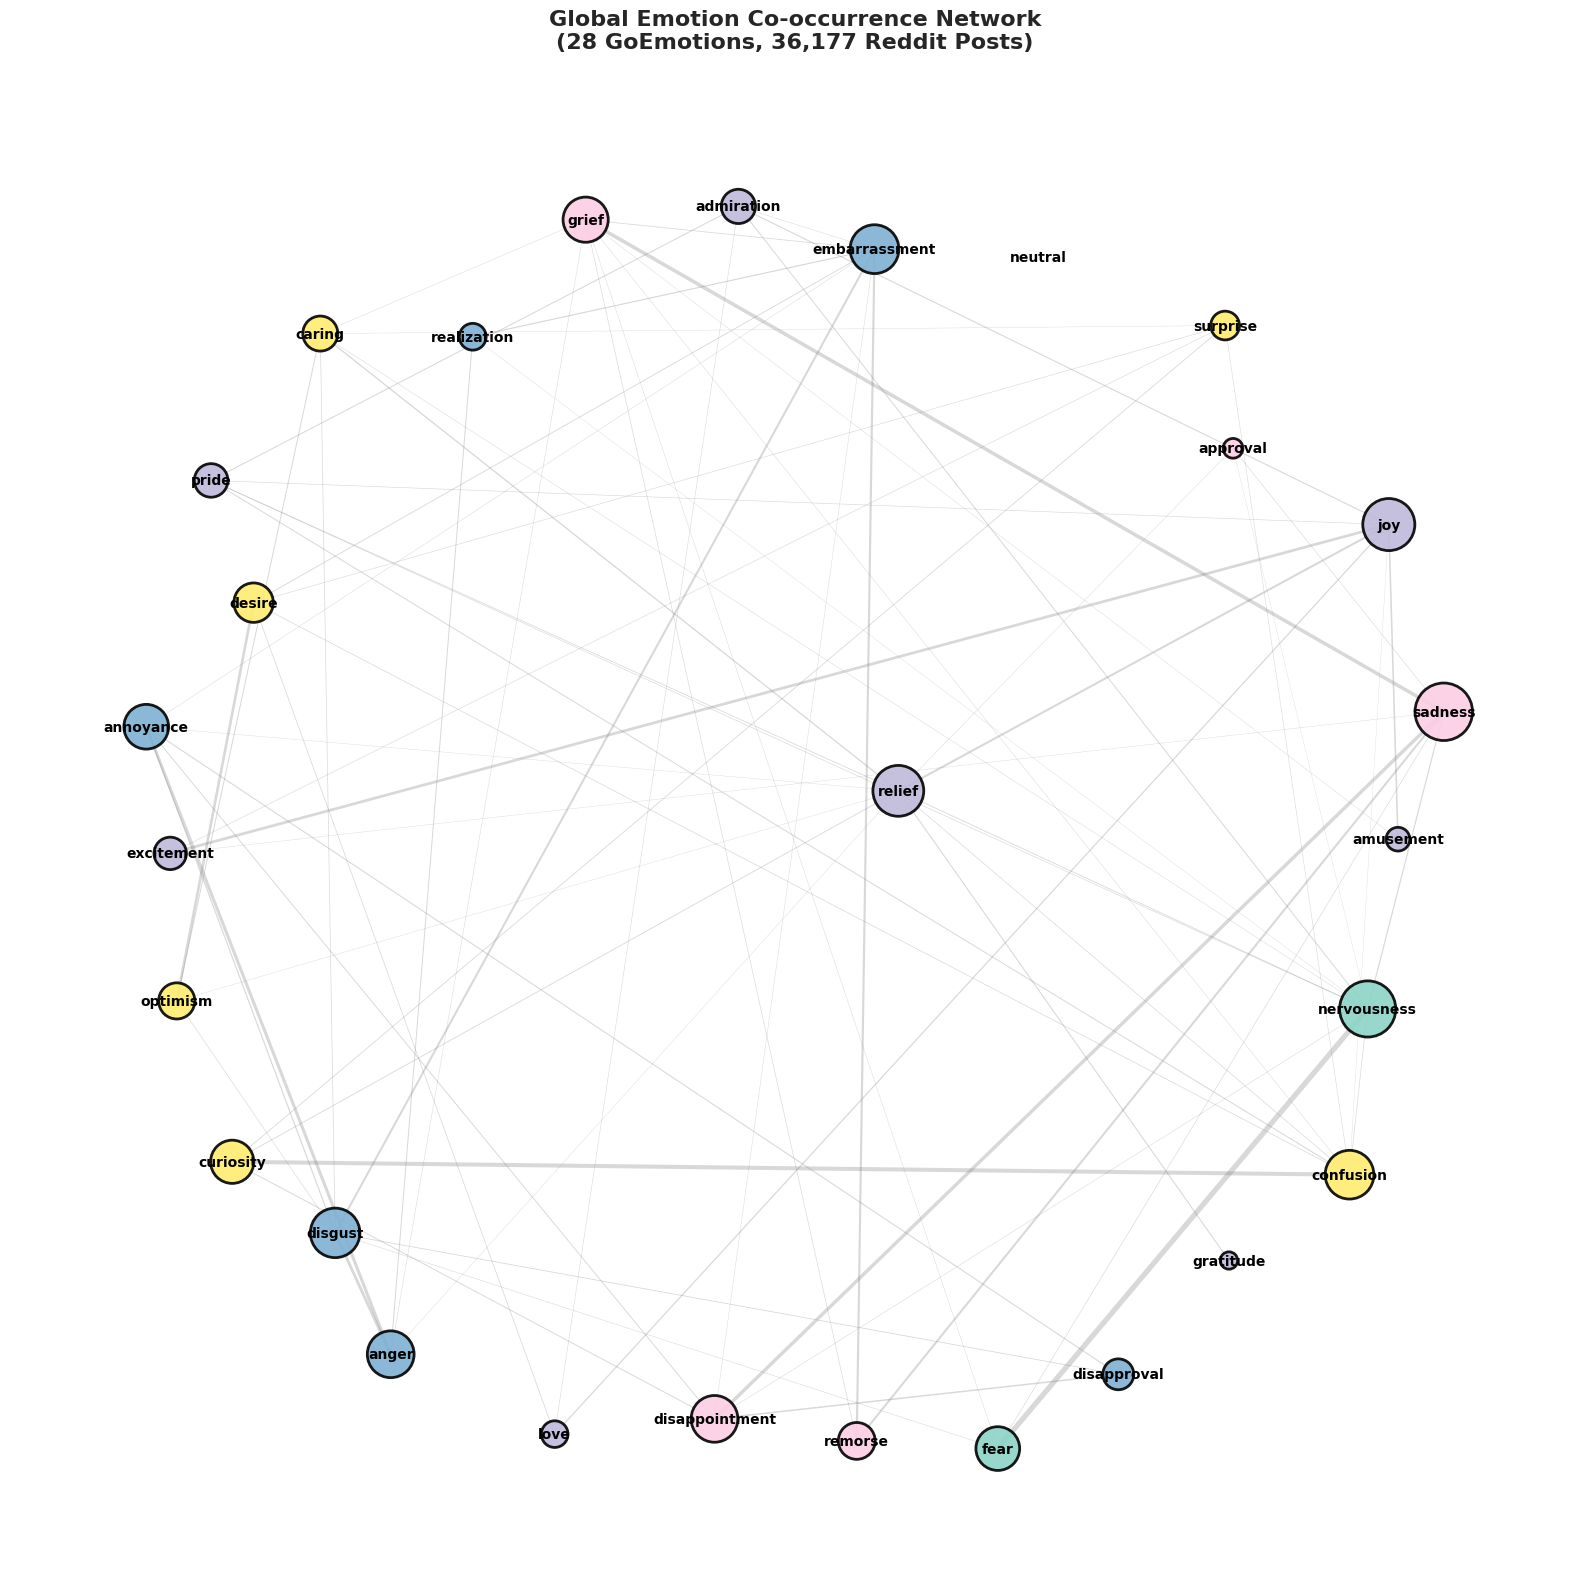

In [34]:
# Static visualization with matplotlib
fig, ax = plt.subplots(figsize=(16, 16))

# Layout
pos = nx.spring_layout(G_global, k=2, iterations=50, seed=42)

# Node colors by community
node_colors = [communities[node] for node in G_global.nodes()]
cmap = plt.cm.Set3

# Node sizes by strength centrality
node_sizes = [strength_centrality[node] * 1000 for node in G_global.nodes()]

# Draw edges
edges = G_global.edges()
weights = [G_global[u][v]['weight'] for u, v in edges]

nx.draw_networkx_edges(
    G_global, pos,
    alpha=0.3,
    width=[w*5 for w in weights],
    edge_color='gray',
    ax=ax
)

# Draw nodes
nx.draw_networkx_nodes(
    G_global, pos,
    node_color=node_colors,
    node_size=node_sizes,
    cmap=cmap,
    alpha=0.9,
    edgecolors='black',
    linewidths=2,
    ax=ax
)

# Draw labels
nx.draw_networkx_labels(
    G_global, pos,
    font_size=10,
    font_weight='bold',
    ax=ax
)

ax.set_title('Global Emotion Co-occurrence Network\n(28 GoEmotions, 36,177 Reddit Posts)',
             fontsize=16, fontweight='bold', pad=20)
ax.axis('off')
plt.tight_layout()

# Save
output_path = NETWORK_DIR / 'global_emotion_network.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"Saved: {output_path}")
plt.show()

In [35]:
# Interactive visualization with pyvis
print("Creating interactive network visualization...")

net = PyvisNetwork(height='800px', width='100%', bgcolor='#ffffff', font_color='black')

# Add nodes
for emotion in G_global.nodes():
    net.add_node(
        emotion,
        label=emotion,
        title=f"{emotion}\nStrength: {strength_centrality[emotion]:.3f}\nCommunity: {communities[emotion]}",
        size=strength_centrality[emotion] * 20,
        color=plt.cm.Set3(communities[emotion] / num_communities)[:3]  # RGB only
    )

# Add edges
for u, v, data in G_global.edges(data=True):
    net.add_edge(
        u, v,
        value=data['weight'] * 10,
        title=f"Partial correlation: {data['weight']:.3f}"
    )

# Physics settings
net.set_options("""
{
  "physics": {
    "forceAtlas2Based": {
      "gravitationalConstant": -50,
      "centralGravity": 0.01,
      "springLength": 100,
      "springConstant": 0.08
    },
    "maxVelocity": 50,
    "solver": "forceAtlas2Based"
  }
}
""")

# Save
interactive_path = NETWORK_DIR / 'global_emotion_network_interactive.html'
net.save_graph(str(interactive_path))
print(f"Saved: {interactive_path}")

Creating interactive network visualization...
Saved: /content/drive/MyDrive/mental_health_research_V2/results/emotion_network/global_emotion_network_interactive.html


## 5. Statistical Validation (Bootstrap)

In [36]:
print("="*60)
print("BOOTSTRAP EDGE STABILITY ANALYSIS")
print("="*60)

from multiprocessing import Pool, cpu_count

N_BOOTSTRAP = 1000
n_samples = len(emotion_probs)
n_cores = min(cpu_count(), 32)

print(f"\nRunning {N_BOOTSTRAP} bootstrap iterations using {n_cores} cores...")

# Define explicit alpha range (same as global network)
alphas_range = np.logspace(-3, 0.5, 30)  # 0.001 to 3.16

def bootstrap_iteration(seed):
    np.random.seed(seed)
    indices = np.random.choice(n_samples, size=n_samples, replace=True)
    sample_data = emotion_probs[indices]

    model_boot = GraphicalLassoCV(cv=5, alphas=alphas_range, max_iter=1000, tol=1e-4, verbose=0)
    model_boot.fit(sample_data)

    precision_boot = model_boot.precision_
    d_boot = np.sqrt(np.diag(precision_boot))
    partial_corr_boot = -precision_boot / np.outer(d_boot, d_boot)
    np.fill_diagonal(partial_corr_boot, 0)

    return partial_corr_boot

with Pool(n_cores) as pool:
    edge_weights_bootstrap = pool.map(bootstrap_iteration, range(N_BOOTSTRAP))
    if (len(edge_weights_bootstrap) % 100 == 0):
        print(f"  Progress: {len(edge_weights_bootstrap)}/{N_BOOTSTRAP}")

edge_weights_bootstrap = np.array(edge_weights_bootstrap)
print(f"\nBootstrap complete! Shape: {edge_weights_bootstrap.shape}")

BOOTSTRAP EDGE STABILITY ANALYSIS

Running 1000 bootstrap iterations using 8 cores...
  Progress: 1000/1000

Bootstrap complete! Shape: (1000, 28, 28)


In [37]:
# Calculate edge stability (proportion of bootstrap samples where edge exists)
edge_stability = np.mean(np.abs(edge_weights_bootstrap) > EDGE_THRESHOLD, axis=0)

# Calculate confidence intervals
edge_ci_lower = np.percentile(edge_weights_bootstrap, 2.5, axis=0)
edge_ci_upper = np.percentile(edge_weights_bootstrap, 97.5, axis=0)

print("\nMost stable edges (appear in >90% of bootstrap samples):\n")

stable_edges = []
for i in range(len(EMOTION_NAMES)):
    for j in range(i+1, len(EMOTION_NAMES)):
        if edge_stability[i, j] > 0.9:
            stable_edges.append({
                'emotion1': EMOTION_NAMES[i],
                'emotion2': EMOTION_NAMES[j],
                'stability': edge_stability[i, j],
                'mean_weight': partial_corr[i, j],
                'ci_lower': edge_ci_lower[i, j],
                'ci_upper': edge_ci_upper[i, j]
            })

stable_edges_df = pd.DataFrame(stable_edges).sort_values('stability', ascending=False)
print(stable_edges_df.head(20).to_string(index=False))

print(f"\nTotal stable edges: {len(stable_edges_df)}")


Most stable edges (appear in >90% of bootstrap samples):

  emotion1       emotion2  stability  mean_weight  ci_lower  ci_upper
admiration  embarrassment        1.0    -0.073744 -0.078284 -0.068808
admiration            joy        1.0     0.161308  0.153442  0.169132
admiration           love        1.0     0.078597  0.063250  0.092595
admiration    nervousness        1.0    -0.144487 -0.147735 -0.141080
admiration          pride        1.0     0.150828  0.129686  0.172808
 amusement          grief        1.0    -0.064456 -0.069562 -0.059497
 amusement            joy        1.0     0.227139  0.217446  0.235823
     anger      annoyance        1.0     0.444498  0.437870  0.450550
     anger        disgust        1.0     0.414736  0.408002  0.420836
     anger          grief        1.0     0.073612  0.068646  0.077947
     anger    realization        1.0    -0.143863 -0.149085 -0.137599
     anger         relief        1.0    -0.058491 -0.061821 -0.054361
 annoyance disappointment      

## 6. Topic-Stratified Networks

In [38]:
print("="*60)
print("TOPIC-STRATIFIED EMOTION NETWORKS")
print("="*60)

# Analyze ALL topics (not just top 5)
topic_counts = df['topic'].value_counts()
all_topics = topic_counts[topic_counts.index != -1].index.tolist()

print(f"\nAnalyzing all {len(all_topics)} topics:")
for topic_id in all_topics[:10]:
    count = topic_counts[topic_id]
    print(f"  Topic {topic_id}: {count:,} posts")
if len(all_topics) > 10:
    print(f"  ... and {len(all_topics) - 10} more topics")

topic_networks = {}

# Define explicit alpha range (same as global network)
alphas_range = np.logspace(-3, 0.5, 30)  # 0.001 to 3.16

for topic_id in all_topics:
    if (all_topics.index(topic_id) + 1) % 5 == 0:
        print(f"  Building networks: {all_topics.index(topic_id) + 1}/{len(all_topics)}")

    topic_posts = df[df['topic'] == topic_id]
    topic_emotions = topic_posts[EMOTION_NAMES].values

    model_topic = GraphicalLassoCV(cv=5, alphas=alphas_range, max_iter=1000, tol=1e-4, verbose=0)
    model_topic.fit(topic_emotions)

    precision_topic = model_topic.precision_
    d_topic = np.sqrt(np.diag(precision_topic))
    partial_corr_topic = -precision_topic / np.outer(d_topic, d_topic)
    np.fill_diagonal(partial_corr_topic, 0)

    G_topic = nx.Graph()
    for emotion in EMOTION_NAMES:
        G_topic.add_node(emotion)

    for i, emotion1 in enumerate(EMOTION_NAMES):
        for j, emotion2 in enumerate(EMOTION_NAMES):
            if i < j:
                weight = partial_corr_topic[i, j]
                if abs(weight) > EDGE_THRESHOLD:
                    G_topic.add_edge(emotion1, emotion2, weight=abs(weight))

    topic_networks[topic_id] = {
        'graph': G_topic,
        'partial_corr': partial_corr_topic,
        'n_posts': len(topic_posts)
    }

print(f"\nBuilt {len(topic_networks)} topic-specific emotion networks")

TOPIC-STRATIFIED EMOTION NETWORKS

Analyzing all 19 topics:
  Topic 0: 15,981 posts
  Topic 1: 2,559 posts
  Topic 2: 2,133 posts
  Topic 3: 1,461 posts
  Topic 4: 1,452 posts
  Topic 13: 1,099 posts
  Topic 5: 818 posts
  Topic 9: 815 posts
  Topic 6: 674 posts
  Topic 7: 647 posts
  ... and 9 more topics
  Building networks: 5/19
  Building networks: 10/19
  Building networks: 15/19

Built 19 topic-specific emotion networks


In [39]:
# Compare network properties across topics
print("\nNetwork properties by topic:\n")

comparison_data = []
for topic_id, network_data in topic_networks.items():
    G = network_data['graph']
    comparison_data.append({
        'topic': topic_id,
        'n_posts': network_data['n_posts'],
        'n_edges': G.number_of_edges(),
        'density': nx.density(G),
        'avg_clustering': nx.average_clustering(G)
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))


Network properties by topic:

 topic  n_posts  n_edges  density  avg_clustering
     0    15981       65 0.171958        0.259269
     1     2559       65 0.171958        0.243568
     2     2133       67 0.177249        0.203401
     3     1461       60 0.158730        0.269019
     4     1452       64 0.169312        0.147619
    13     1099       67 0.177249        0.288786
     5      818       59 0.156085        0.195132
     9      815       80 0.211640        0.232841
     6      674       61 0.161376        0.221315
     7      647       62 0.164021        0.233929
    14      602       66 0.174603        0.237840
    16      569       65 0.171958        0.255215
    17      453       68 0.179894        0.258844
    18      429       63 0.166667        0.237217
    11      426       52 0.137566        0.164881
    10      413       65 0.171958        0.191327
    15      407       65 0.171958        0.267319
     8      353       74 0.195767        0.262588
    12      248    

In [40]:
# Visualize all topic networks
print("\nGenerating visualizations for all topic networks...")

for idx, (topic_id, network_data) in enumerate(topic_networks.items()):
    if (idx + 1) % 5 == 0:
        print(f"  Visualizing: {idx + 1}/{len(topic_networks)}")

    G = network_data['graph']
    n_posts = network_data['n_posts']

    # Skip if no edges
    if G.number_of_edges() == 0:
        continue

    fig, ax = plt.subplots(figsize=(14, 14))

    # Layout
    pos = nx.spring_layout(G, k=2, iterations=50, seed=42)

    # Node sizes by degree
    node_sizes = [G.degree(node, weight='weight') * 500 for node in G.nodes()]

    # Draw edges
    edges = G.edges()
    if len(edges) > 0:
        weights = [G[u][v]['weight'] for u, v in edges]
        nx.draw_networkx_edges(
            G, pos,
            alpha=0.4,
            width=[w*8 for w in weights],
            edge_color='gray',
            ax=ax
        )

    # Draw nodes
    nx.draw_networkx_nodes(
        G, pos,
        node_color='lightblue',
        node_size=node_sizes,
        alpha=0.9,
        edgecolors='black',
        linewidths=2,
        ax=ax
    )

    # Draw labels
    nx.draw_networkx_labels(
        G, pos,
        font_size=9,
        font_weight='bold',
        ax=ax
    )

    ax.set_title(f'Topic {topic_id} Emotion Network\n({n_posts:,} posts, {G.number_of_edges()} edges)',
                 fontsize=14, fontweight='bold', pad=20)
    ax.axis('off')
    plt.tight_layout()

    # Save
    output_path = NETWORK_DIR / f'topic_{topic_id}_network.png'
    plt.savefig(output_path, dpi=200, bbox_inches='tight')
    plt.close()

print(f"\nSaved {len(topic_networks)} topic network visualizations")


Generating visualizations for all topic networks...
  Visualizing: 5/19
  Visualizing: 10/19
  Visualizing: 15/19

Saved 19 topic network visualizations


## 6.5. Subreddit-Level Networks

In [41]:
print("="*60)
print("SUBREDDIT-LEVEL EMOTION NETWORKS")
print("="*60)

if 'subreddit' in df.columns:
    subreddit_counts = df['subreddit'].value_counts()
    print(f"\nAnalyzing {len(subreddit_counts)} subreddits:")

    subreddit_networks = {}

    # Define explicit alpha range (same as global network)
    alphas_range = np.logspace(-3, 0.5, 30)  # 0.001 to 3.16

    for subreddit in subreddit_counts.index:
        subreddit_posts = df[df['subreddit'] == subreddit]
        n_posts = len(subreddit_posts)

        if n_posts < 100:
            continue

        if (list(subreddit_counts.index).index(subreddit) + 1) % 5 == 0:
            print(f"  Building networks: {list(subreddit_counts.index).index(subreddit) + 1}/{len(subreddit_counts)}")

        subreddit_emotions = subreddit_posts[EMOTION_NAMES].values

        model_subreddit = GraphicalLassoCV(cv=5, alphas=alphas_range, max_iter=1000, tol=1e-4, verbose=0)
        model_subreddit.fit(subreddit_emotions)

        precision_subreddit = model_subreddit.precision_
        d_subreddit = np.sqrt(np.diag(precision_subreddit))
        partial_corr_subreddit = -precision_subreddit / np.outer(d_subreddit, d_subreddit)
        np.fill_diagonal(partial_corr_subreddit, 0)

        G_subreddit = nx.Graph()
        for emotion in EMOTION_NAMES:
            G_subreddit.add_node(emotion)

        for i, emotion1 in enumerate(EMOTION_NAMES):
            for j, emotion2 in enumerate(EMOTION_NAMES):
                if i < j:
                    weight = partial_corr_subreddit[i, j]
                    if abs(weight) > EDGE_THRESHOLD:
                        G_subreddit.add_edge(emotion1, emotion2, weight=abs(weight))

        subreddit_networks[subreddit] = {
            'graph': G_subreddit,
            'partial_corr': partial_corr_subreddit,
            'n_posts': n_posts
        }

    print(f"\nBuilt {len(subreddit_networks)} subreddit-specific emotion networks")

    subreddit_comparison = []
    for subreddit, network_data in subreddit_networks.items():
        G = network_data['graph']
        subreddit_comparison.append({
            'subreddit': subreddit,
            'n_posts': network_data['n_posts'],
            'n_edges': G.number_of_edges(),
            'density': nx.density(G),
            'avg_clustering': nx.average_clustering(G)
        })

    subreddit_comparison_df = pd.DataFrame(subreddit_comparison).sort_values('n_posts', ascending=False)
    print("\nNetwork properties by subreddit:\n")
    print(subreddit_comparison_df.to_string(index=False))
else:
    print("\nSubreddit column not found, skipping subreddit analysis")

SUBREDDIT-LEVEL EMOTION NETWORKS

Analyzing 18 subreddits:
  Building networks: 5/18
  Building networks: 10/18
  Building networks: 15/18

Built 18 subreddit-specific emotion networks

Network properties by subreddit:

         subreddit  n_posts  n_edges  density  avg_clustering
      SuicideWatch     2625       60 0.158730        0.194728
              ADHD     2623       63 0.166667        0.210091
      mentalhealth     2525       63 0.166667        0.222194
        depression     2505       57 0.150794        0.210119
           Anxiety     2395       54 0.142857        0.261526
               BPD     2390       68 0.179894        0.236536
               OCD     2268       64 0.169312        0.248866
            autism     2265       66 0.174603        0.193707
           bipolar     2187       69 0.182540        0.248129
     socialanxiety     1911       61 0.161376        0.267914
              ptsd     1874       65 0.171958        0.256378
     BipolarReddit     1829       66

In [42]:
# Visualize all subreddit networks
if 'subreddit_networks' in locals():
    print("\nGenerating visualizations for all subreddit networks...")

    for idx, (subreddit, network_data) in enumerate(subreddit_networks.items()):
        if (idx + 1) % 5 == 0:
            print(f"  Visualizing: {idx + 1}/{len(subreddit_networks)}")

        G = network_data['graph']
        n_posts = network_data['n_posts']

        # Skip if no edges
        if G.number_of_edges() == 0:
            continue

        fig, ax = plt.subplots(figsize=(14, 14))

        # Layout
        pos = nx.spring_layout(G, k=2, iterations=50, seed=42)

        # Node sizes by degree
        node_sizes = [G.degree(node, weight='weight') * 500 for node in G.nodes()]

        # Draw edges
        edges = G.edges()
        if len(edges) > 0:
            weights = [G[u][v]['weight'] for u, v in edges]
            nx.draw_networkx_edges(
                G, pos,
                alpha=0.4,
                width=[w*8 for w in weights],
                edge_color='gray',
                ax=ax
            )

        # Draw nodes
        nx.draw_networkx_nodes(
            G, pos,
            node_color='lightcoral',
            node_size=node_sizes,
            alpha=0.9,
            edgecolors='black',
            linewidths=2,
            ax=ax
        )

        # Draw labels
        nx.draw_networkx_labels(
            G, pos,
            font_size=9,
            font_weight='bold',
            ax=ax
        )

        ax.set_title(f'r/{subreddit} Emotion Network\n({n_posts:,} posts, {G.number_of_edges()} edges)',
                     fontsize=14, fontweight='bold', pad=20)
        ax.axis('off')
        plt.tight_layout()

        # Save
        output_path = NETWORK_DIR / f'{subreddit.lower()}_network.png'
        plt.savefig(output_path, dpi=200, bbox_inches='tight')
        plt.close()

    print(f"\nSaved {len(subreddit_networks)} subreddit network visualizations")


Generating visualizations for all subreddit networks...
  Visualizing: 5/18
  Visualizing: 10/18
  Visualizing: 15/18

Saved 18 subreddit network visualizations


In [43]:
# Create comparison heatmaps for topics and subreddits
print("Creating network comparison heatmaps...")

# Topic comparison heatmap
if len(topic_networks) > 0:
    # Prepare data for heatmap
    topic_metrics = []
    for topic_id in sorted(topic_networks.keys()):
        network_data = topic_networks[topic_id]
        G = network_data['graph']

        # Calculate average edge weight
        if G.number_of_edges() > 0:
            avg_edge_weight = np.mean([data['weight'] for u, v, data in G.edges(data=True)])
        else:
            avg_edge_weight = 0

        topic_metrics.append({
            'Topic': f'T{topic_id}',
            'Posts': network_data['n_posts'],
            'Edges': G.number_of_edges(),
            'Density': nx.density(G),
            'Avg Edge Weight': avg_edge_weight
        })

    topic_metrics_df = pd.DataFrame(topic_metrics).set_index('Topic')

    # Create heatmap
    fig, ax = plt.subplots(figsize=(10, 8))

    # Normalize for better visualization
    topic_metrics_normalized = topic_metrics_df.copy()
    for col in topic_metrics_normalized.columns:
        topic_metrics_normalized[col] = (topic_metrics_normalized[col] - topic_metrics_normalized[col].min()) / \
                                         (topic_metrics_normalized[col].max() - topic_metrics_normalized[col].min() + 1e-10)

    sns.heatmap(topic_metrics_normalized.T, annot=False, cmap='YlOrRd',
                cbar_kws={'label': 'Normalized Value'}, ax=ax)
    ax.set_title('Topic Network Comparison (Normalized Metrics)', fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel('Topic ID', fontsize=12)
    ax.set_ylabel('Network Metric', fontsize=12)
    plt.tight_layout()

    output_path = NETWORK_DIR / 'topic_network_comparison_heatmap.png'
    plt.savefig(output_path, dpi=200, bbox_inches='tight')
    plt.close()
    print(f"Saved: {output_path}")

# Subreddit comparison heatmap
if 'subreddit_networks' in locals() and len(subreddit_networks) > 0:
    # Prepare data for heatmap
    subreddit_metrics = []
    for subreddit in sorted(subreddit_networks.keys()):
        network_data = subreddit_networks[subreddit]
        G = network_data['graph']

        # Calculate average edge weight
        if G.number_of_edges() > 0:
            avg_edge_weight = np.mean([data['weight'] for u, v, data in G.edges(data=True)])
        else:
            avg_edge_weight = 0

        subreddit_metrics.append({
            'Subreddit': subreddit,
            'Posts': network_data['n_posts'],
            'Edges': G.number_of_edges(),
            'Density': nx.density(G),
            'Avg Edge Weight': avg_edge_weight
        })

    subreddit_metrics_df = pd.DataFrame(subreddit_metrics).set_index('Subreddit')

    # Create heatmap
    fig, ax = plt.subplots(figsize=(10, 10))

    # Normalize for better visualization
    subreddit_metrics_normalized = subreddit_metrics_df.copy()
    for col in subreddit_metrics_normalized.columns:
        subreddit_metrics_normalized[col] = (subreddit_metrics_normalized[col] - subreddit_metrics_normalized[col].min()) / \
                                              (subreddit_metrics_normalized[col].max() - subreddit_metrics_normalized[col].min() + 1e-10)

    sns.heatmap(subreddit_metrics_normalized.T, annot=False, cmap='Blues',
                cbar_kws={'label': 'Normalized Value'}, ax=ax)
    ax.set_title('Subreddit Network Comparison (Normalized Metrics)', fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel('Subreddit', fontsize=12)
    ax.set_ylabel('Network Metric', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    output_path = NETWORK_DIR / 'subreddit_network_comparison_heatmap.png'
    plt.savefig(output_path, dpi=200, bbox_inches='tight')
    plt.close()
    print(f"Saved: {output_path}")

print("\nComparison visualizations complete!")

Creating network comparison heatmaps...
Saved: /content/drive/MyDrive/mental_health_research_V2/results/emotion_network/topic_network_comparison_heatmap.png
Saved: /content/drive/MyDrive/mental_health_research_V2/results/emotion_network/subreddit_network_comparison_heatmap.png

Comparison visualizations complete!


## 6.8. Network Comparison Visualizations

In [44]:
# Export detailed partial correlations and edge lists for each topic
print("Exporting detailed topic network data...")

# Create subdirectories
TOPIC_DETAIL_DIR = NETWORK_DIR / "topic_details"
SUBREDDIT_DETAIL_DIR = NETWORK_DIR / "subreddit_details"
TOPIC_DETAIL_DIR.mkdir(exist_ok=True)
SUBREDDIT_DETAIL_DIR.mkdir(exist_ok=True)

# Topic networks
for topic_id, network_data in topic_networks.items():
    # Save partial correlation matrix
    partial_corr_topic = network_data['partial_corr']
    partial_corr_df = pd.DataFrame(partial_corr_topic, index=EMOTION_NAMES, columns=EMOTION_NAMES)
    partial_corr_path = TOPIC_DETAIL_DIR / f"topic_{topic_id}_partial_correlations.csv"
    partial_corr_df.to_csv(partial_corr_path)

    # Save edge list
    G = network_data['graph']
    if G.number_of_edges() > 0:
        edge_list = []
        for u, v, data in G.edges(data=True):
            edge_list.append({
                'emotion1': u,
                'emotion2': v,
                'weight': data['weight']
            })
        edge_df = pd.DataFrame(edge_list)
        edge_path = TOPIC_DETAIL_DIR / f"topic_{topic_id}_edges.csv"
        edge_df.to_csv(edge_path, index=False)

print(f"Saved detailed data for {len(topic_networks)} topics to {TOPIC_DETAIL_DIR}")

# Subreddit networks
if 'subreddit_networks' in locals():
    print("\nExporting detailed subreddit network data...")

    for subreddit, network_data in subreddit_networks.items():
        # Save partial correlation matrix
        partial_corr_subreddit = network_data['partial_corr']
        partial_corr_df = pd.DataFrame(partial_corr_subreddit, index=EMOTION_NAMES, columns=EMOTION_NAMES)
        partial_corr_path = SUBREDDIT_DETAIL_DIR / f"{subreddit.lower()}_partial_correlations.csv"
        partial_corr_df.to_csv(partial_corr_path)

        # Save edge list
        G = network_data['graph']
        if G.number_of_edges() > 0:
            edge_list = []
            for u, v, data in G.edges(data=True):
                edge_list.append({
                    'emotion1': u,
                    'emotion2': v,
                    'weight': data['weight']
                })
            edge_df = pd.DataFrame(edge_list)
            edge_path = SUBREDDIT_DETAIL_DIR / f"{subreddit.lower()}_edges.csv"
            edge_df.to_csv(edge_path, index=False)

    print(f"Saved detailed data for {len(subreddit_networks)} subreddits to {SUBREDDIT_DETAIL_DIR}")

Exporting detailed topic network data...
Saved detailed data for 19 topics to /content/drive/MyDrive/mental_health_research_V2/results/emotion_network/topic_details

Exporting detailed subreddit network data...
Saved detailed data for 18 subreddits to /content/drive/MyDrive/mental_health_research_V2/results/emotion_network/subreddit_details


## 6.7. Detailed Network Data Exports

## 7. Save Results

In [45]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Save centrality metrics
centrality_path = NETWORK_DIR / f"emotion_centrality_{timestamp}.csv"
centrality_df.to_csv(centrality_path, index=False)
print(f"Saved centrality metrics: {centrality_path}")

# Save stable edges
if len(stable_edges_df) > 0:
    stable_edges_path = NETWORK_DIR / f"stable_edges_{timestamp}.csv"
    stable_edges_df.to_csv(stable_edges_path, index=False)
    print(f"Saved stable edges: {stable_edges_path}")

# Save topic comparison
comparison_path = NETWORK_DIR / f"topic_network_comparison_{timestamp}.csv"
comparison_df.to_csv(comparison_path, index=False)
print(f"Saved topic comparison: {comparison_path}")

# Save subreddit comparison
if 'subreddit_comparison_df' in locals():
    subreddit_path = NETWORK_DIR / f"subreddit_network_comparison_{timestamp}.csv"
    subreddit_comparison_df.to_csv(subreddit_path, index=False)
    print(f"Saved subreddit comparison: {subreddit_path}")

# Save partial correlation matrix
partial_corr_df = pd.DataFrame(partial_corr, index=EMOTION_NAMES, columns=EMOTION_NAMES)
partial_corr_path = NETWORK_DIR / f"partial_correlations_{timestamp}.csv"
partial_corr_df.to_csv(partial_corr_path)
print(f"Saved partial correlations: {partial_corr_path}")

print(f"\nAll results saved to: {NETWORK_DIR}")

Saved centrality metrics: /content/drive/MyDrive/mental_health_research_V2/results/emotion_network/emotion_centrality_20251123_215617.csv
Saved stable edges: /content/drive/MyDrive/mental_health_research_V2/results/emotion_network/stable_edges_20251123_215617.csv
Saved topic comparison: /content/drive/MyDrive/mental_health_research_V2/results/emotion_network/topic_network_comparison_20251123_215617.csv
Saved subreddit comparison: /content/drive/MyDrive/mental_health_research_V2/results/emotion_network/subreddit_network_comparison_20251123_215617.csv
Saved partial correlations: /content/drive/MyDrive/mental_health_research_V2/results/emotion_network/partial_correlations_20251123_215617.csv

All results saved to: /content/drive/MyDrive/mental_health_research_V2/results/emotion_network


## 8. Summary

In [46]:
print("="*60)
print("EMOTION NETWORK ANALYSIS COMPLETE")
print("="*60)

print(f"\nGlobal Network:")
print(f"  Total posts analyzed: {len(df):,}")
print(f"  Emotions (nodes): {G_global.number_of_nodes()}")
print(f"  Connections (edges): {G_global.number_of_edges()}")
print(f"  Communities detected: {num_communities}")
print(f"  Bootstrap iterations: {N_BOOTSTRAP}")
print(f"  Stable edges (>90% bootstrap): {len(stable_edges_df)}")

print(f"\nTop 3 Most Central Emotions:")
for idx, row in centrality_df.head(3).iterrows():
    print(f"  {row['emotion']}: strength={row['strength']:.3f}, betweenness={row['betweenness']:.3f}")

print(f"\nTopic-Specific Networks:")
print(f"  Analyzed {len(topic_networks)} topics")
print(f"  Generated {len(topic_networks)} network visualizations")
print(f"  Exported {len(topic_networks)} partial correlation matrices")

if 'subreddit_networks' in locals():
    print(f"\nSubreddit-Specific Networks:")
    print(f"  Analyzed {len(subreddit_networks)} subreddits")
    print(f"  Generated {len(subreddit_networks)} network visualizations")
    print(f"  Exported {len(subreddit_networks)} partial correlation matrices")

print(f"\nAll Output Files:")
print(f"  Global Network:")
print(f"    - global_emotion_network.png (high-res visualization)")
print(f"    - global_emotion_network_interactive.html (interactive graph)")
print(f"    - emotion_centrality_TIMESTAMP.csv (centrality metrics)")
print(f"    - stable_edges_TIMESTAMP.csv (bootstrap-validated edges)")
print(f"    - partial_correlations_TIMESTAMP.csv (28×28 matrix)")
print(f"  ")
print(f"  Topic Networks (19 total):")
print(f"    - topic_ID_network.png (19 visualizations)")
print(f"    - topic_network_comparison_TIMESTAMP.csv (metrics table)")
print(f"    - topic_network_comparison_heatmap.png (comparison viz)")
print(f"    - topic_details/ directory:")
print(f"        • topic_ID_partial_correlations.csv (19 matrices)")
print(f"        • topic_ID_edges.csv (edge lists)")
print(f"  ")
print(f"  Subreddit Networks (18 total):")
print(f"    - SUBREDDIT_network.png (18 visualizations)")
print(f"    - subreddit_network_comparison_TIMESTAMP.csv (metrics table)")
print(f"    - subreddit_network_comparison_heatmap.png (comparison viz)")
print(f"    - subreddit_details/ directory:")
print(f"        • SUBREDDIT_partial_correlations.csv (18 matrices)")
print(f"        • SUBREDDIT_edges.csv (edge lists)")

print(f"\nAll files saved to: {NETWORK_DIR}")
print(f"  - Main directory: {len([f for f in NETWORK_DIR.iterdir() if f.is_file()])} files")
print(f"  - topic_details/: Detailed data for all 19 topics")
print(f"  - subreddit_details/: Detailed data for all 18 subreddits")
print(f"\nTotal: ~60+ output files for comprehensive network analysis!")

EMOTION NETWORK ANALYSIS COMPLETE

Global Network:
  Total posts analyzed: 36,177
  Emotions (nodes): 28
  Connections (edges): 71
  Communities detected: 6
  Bootstrap iterations: 1000
  Stable edges (>90% bootstrap): 69

Top 3 Most Central Emotions:
  sadness: strength=1.715, betweenness=0.043
  nervousness: strength=1.636, betweenness=0.148
  joy: strength=1.406, betweenness=0.023

Topic-Specific Networks:
  Analyzed 19 topics
  Generated 19 network visualizations
  Exported 19 partial correlation matrices

Subreddit-Specific Networks:
  Analyzed 18 subreddits
  Generated 18 network visualizations
  Exported 18 partial correlation matrices

All Output Files:
  Global Network:
    - global_emotion_network.png (high-res visualization)
    - global_emotion_network_interactive.html (interactive graph)
    - emotion_centrality_TIMESTAMP.csv (centrality metrics)
    - stable_edges_TIMESTAMP.csv (bootstrap-validated edges)
    - partial_correlations_TIMESTAMP.csv (28×28 matrix)
  
  Topic 